In [55]:
import pandas as pd
import requests
import json

import matplotlib.pyplot as plt


In [56]:
df = pd.read_csv('agriculture_dataset.csv')
print(df.columns)
#note: crop type is object
df.head()

Index(['High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images',
       'Temporal_Images', 'Spatial_Resolution', 'GPS_Coordinates',
       'Field_Boundaries', 'Elevation_Data', 'Canopy_Coverage', 'NDVI', 'SAVI',
       'Chlorophyll_Content', 'Leaf_Area_Index', 'Crop_Stress_Indicator',
       'Temperature', 'Humidity', 'Rainfall', 'Wind_Speed', 'Soil_Moisture',
       'Soil_pH', 'Organic_Matter', 'Pest_Hotspots', 'Weed_Coverage',
       'Pest_Damage', 'Crop_Growth_Stage', 'Expected_Yield', 'Crop_Type',
       'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Water_Flow',
       'Drainage_Features', 'Crop_Health_Label'],
      dtype='object')


,High_Resolution_RGB,Multispectral_Images,Thermal_Images,Temporal_Images,Spatial_Resolution,GPS_Coordinates,Field_Boundaries,Elevation_Data,Canopy_Coverage,NDVI,...,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Expected_Yield,Crop_Type,Ground_Truth_Segmentation,Bounding_Boxes,Water_Flow,Drainage_Features,Crop_Health_Label
0,0,0,0,0,0.667324,201538,3,28.207634,8.046926,0.676945,...,1.922274,84,2,2540.784327,Wheat,1,5,41.771884,0,1
1,1,1,0,0,1.459000,215854,3,82.335147,147.512332,0.414781,...,4.851381,56,3,3227.617025,Wheat,0,1,27.564635,0,1
2,0,0,0,0,0.500442,890802,3,83.865629,30.246527,0.723610,...,5.974859,38,1,4609.938146,Maize,1,8,29.510836,0,1
3,0,0,0,0,1.865161,605584,3,20.747905,6.857820,0.405611,...,2.100598,27,2,1409.716754,Maize,0,1,34.822855,0,0
4,0,1,1,1,1.392331,871732,3,22.588815,26.168558,0.465992,...,3.025669,84,4,3905.312588,Rice,0,2,15.493255,1,0


In [57]:
#subselect certain columns (add crop type after scaling)
subDf = df[['GPS_Coordinates', 'Elevation_Data', 'NDVI', 'SAVI', 'Chlorophyll_Content', 
            'Leaf_Area_Index', 'Crop_Stress_Indicator', 'Temperature', 'Humidity', 
            'Rainfall', 'Wind_Speed', 'Soil_Moisture', 'Soil_pH', 'Weed_Coverage', 
            'Crop_Growth_Stage', 'Expected_Yield', 'Water_Flow', 
            'Drainage_Features', 'Crop_Health_Label']]

subDf.head()

#print(subDf.dtypes)

,GPS_Coordinates,Elevation_Data,NDVI,SAVI,Chlorophyll_Content,Leaf_Area_Index,Crop_Stress_Indicator,Temperature,Humidity,Rainfall,Wind_Speed,Soil_Moisture,Soil_pH,Weed_Coverage,Crop_Growth_Stage,Expected_Yield,Water_Flow,Drainage_Features,Crop_Health_Label
0,201538,28.207634,0.676945,0.475536,0.829063,3.107188,79,24.627325,47.240283,7.056089,2.795500,31.010549,6.085810,1.922274,2,2540.784327,41.771884,0,1
1,215854,82.335147,0.414781,0.325712,0.435861,1.287952,88,27.671999,44.408156,14.005230,2.325063,12.429003,6.776880,4.851381,3,3227.617025,27.564635,0,1
2,890802,83.865629,0.723610,0.511144,1.001452,1.229495,59,23.515820,56.268020,46.152684,1.705493,28.454713,6.078783,5.974859,1,4609.938146,29.510836,0,1
3,605584,20.747905,0.405611,0.162857,0.962720,0.995907,11,11.473797,38.637011,15.168736,5.891225,28.450994,6.596315,2.100598,2,1409.716754,34.822855,0,0
4,871732,22.588815,0.465992,0.269888,2.111205,0.438672,79,22.502605,64.438963,9.492281,2.281165,8.295005,7.664008,3.025669,4,3905.312588,15.493255,1,0


In [58]:
#Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled= pd.DataFrame(scaler.fit_transform(subDf), columns=subDf.columns)
df_scaled.head()

,GPS_Coordinates,Elevation_Data,NDVI,SAVI,Chlorophyll_Content,Leaf_Area_Index,Crop_Stress_Indicator,Temperature,Humidity,Rainfall,Wind_Speed,Soil_Moisture,Soil_pH,Weed_Coverage,Crop_Growth_Stage,Expected_Yield,Water_Flow,Drainage_Features,Crop_Health_Label
0,-1.340181,-1.029697,1.177837,0.628747,-0.242148,1.452764,1.021493,-0.072325,-0.739046,-0.648841,0.567093,1.267643,-0.829059,-0.586518,-0.450458,-0.580031,1.159373,-0.500230,0.656237
1,-1.285190,1.054578,-0.570108,-0.617998,-0.799036,-0.444915,1.333064,0.536840,-0.902750,-0.300518,0.233291,-0.878763,0.550467,1.246409,0.443178,0.281020,0.175535,-0.500230,0.656237
2,1.307425,1.113511,1.488973,0.925056,0.002005,-0.505892,0.329115,-0.294710,-0.217221,1.310860,-0.206330,0.972412,-0.843086,1.949441,-1.344094,2.013974,0.310308,-0.500230,0.656237
3,0.211844,-1.316947,-0.631249,-1.973178,-0.052851,-0.749552,-1.332593,-2.704025,-1.236336,-0.242198,2.763689,0.971982,0.190018,-0.474930,-0.450458,-1.997999,0.678159,-0.500230,-1.523840
4,1.234173,-1.246060,-0.228669,-1.082536,1.573734,-1.330815,1.021493,-0.497430,0.255079,-0.526728,0.202143,-1.356292,2.321364,0.103946,1.336814,1.130617,-0.660395,1.999081,-1.523840


In [59]:
#show correlation between features
print(df_scaled.corr())

                       GPS_Coordinates  Elevation_Data      NDVI      SAVI  \
GPS_Coordinates               1.000000        0.000656  0.003998 -0.005414   
Elevation_Data                0.000656        1.000000 -0.001865 -0.001159   
NDVI                          0.003998       -0.001865  1.000000 -0.005799   
SAVI                         -0.005414       -0.001159 -0.005799  1.000000   
Chlorophyll_Content          -0.000530        0.000163 -0.002901 -0.001235   
Leaf_Area_Index               0.002248        0.003381  0.000648  0.002637   
Crop_Stress_Indicator         0.004486       -0.001835 -0.004252  0.003312   
Temperature                  -0.003119        0.001055 -0.002460  0.001651   
Humidity                     -0.003229        0.000855  0.000391  0.001759   
Rainfall                      0.001815       -0.002029 -0.000773  0.001959   
Wind_Speed                    0.001883        0.000016  0.000674  0.002376   
Soil_Moisture                -0.000116        0.002725  0.002506

<Axes: >

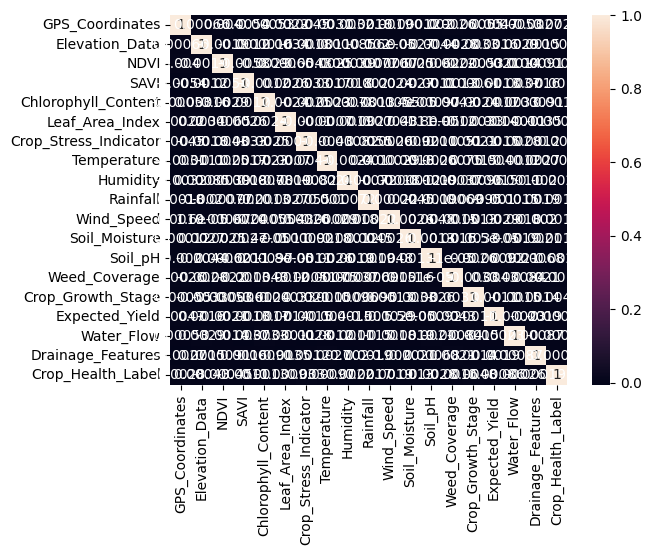

In [60]:
#heatmap for correlation
import seaborn as sns
sns.heatmap(df_scaled.corr(), annot=True)

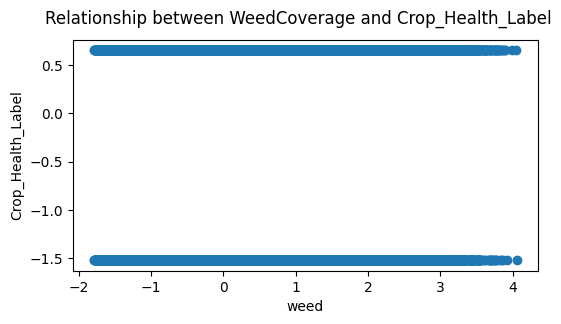

In [61]:
plt.scatter(df_scaled['Weed_Coverage'], df_scaled['Crop_Health_Label'])
plt.xlabel('weed')
plt.ylabel('Crop_Health_Label')
plt.suptitle('Relationship between WeedCoverage and Crop_Health_Label')
plt.gcf().set_size_inches(6, 3)

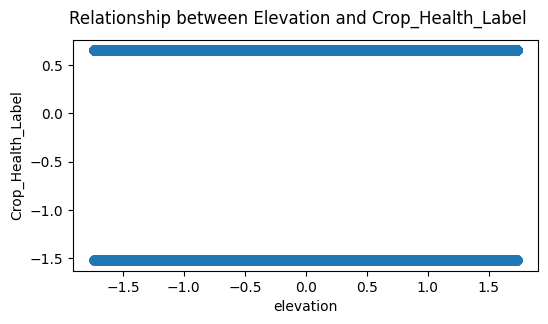

In [62]:
plt.scatter(df_scaled['Humidity'], df_scaled['Crop_Health_Label'])
plt.xlabel('elevation')
plt.ylabel('Crop_Health_Label')
plt.suptitle('Relationship between Elevation and Crop_Health_Label')
plt.gcf().set_size_inches(6, 3)

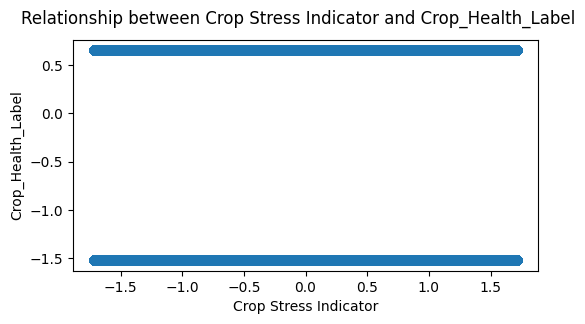

In [63]:
plt.scatter(df_scaled['Crop_Stress_Indicator'], df_scaled['Crop_Health_Label'])
plt.xlabel('Crop Stress Indicator')
plt.ylabel('Crop_Health_Label')
plt.suptitle('Relationship between Crop Stress Indicator and Crop_Health_Label')
plt.gcf().set_size_inches(6, 3)


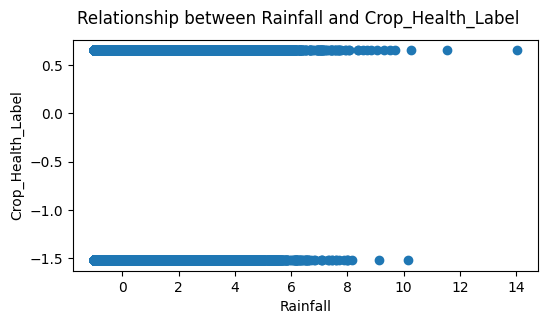

In [64]:
plt.scatter(df_scaled['Rainfall'], df_scaled['Crop_Health_Label'])
plt.xlabel('Rainfall')
plt.ylabel('Crop_Health_Label')
plt.suptitle('Relationship between Rainfall and Crop_Health_Label')
plt.gcf().set_size_inches(6, 3)

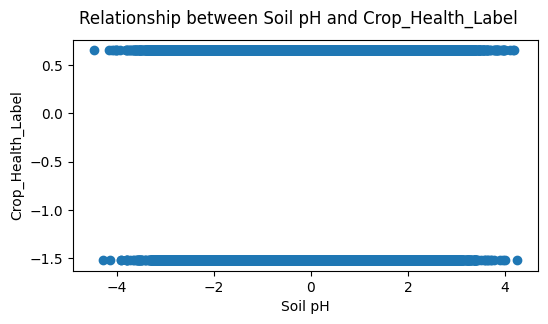

In [65]:
plt.scatter(df_scaled['Soil_pH'], df_scaled['Crop_Health_Label'])
plt.xlabel('Soil pH')
plt.ylabel('Crop_Health_Label')
plt.suptitle('Relationship between Soil pH and Crop_Health_Label')
plt.gcf().set_size_inches(6, 3)

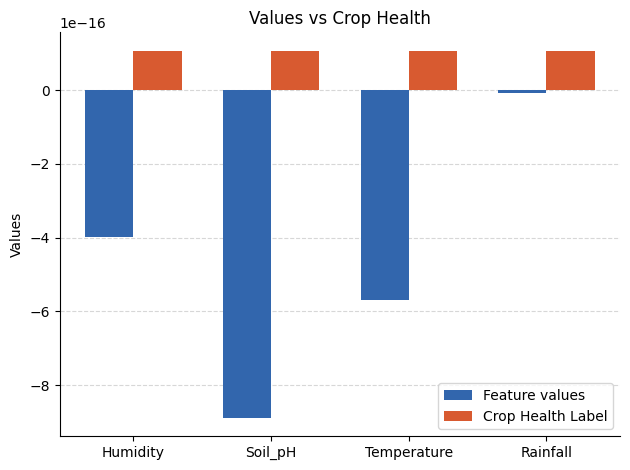

In [66]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Humidity', 'Soil_pH', 'Temperature', 'Rainfall']
values = [
    df_scaled['Humidity'].mean(),
    df_scaled['Soil_pH'].mean(),
    df_scaled['Temperature'].mean(),
    df_scaled['Rainfall'].mean()
]
binary = [df_scaled['Crop_Health_Label'].mean()] * len(labels)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, values, width, label='Feature values', color='#3266ad', edgecolor='none')
ax.bar(x + width/2, binary, width, label='Crop Health Label', color='#D85A30', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Values')
ax.set_title('Values vs Crop Health')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()